We are calculating PFE and EE in this file under the MPOR model

In [1]:
import numpy as np
import pandas as pd
import StocksAndAgents
import ImpactFunctions
import UnpeturbedStockPathGeneration
from scipy.linalg import cholesky
import matplotlib.pyplot as plt

In [2]:

MPOR = 10
start = 0
end = MPOR
portfolio_value = 16922
margin = 1692
portfolio_multiplier = 3
risk_aversion = 0.01
general_lambda = 0.04
steps = 300

agent_names = ["Credit Suisse", "Other Agents"]
start_times = np.array([0, 0])
end_times = np.array([MPOR, MPOR])
times = np.linspace(start, end, steps)
risk_aversions = np.array([risk_aversion, risk_aversion])

portfolio_values = [16922, portfolio_multiplier * portfolio_value]
margins = [margin, margin * portfolio_multiplier]

portfolio_value_dict = {agent_names[i]: portfolio_values[i] for i in range(len(agent_names))}
margins_dict = {agent_names[i]: margins[i] for i in range(len(agent_names))}


stock_names = ["BIDU", "DISCA", "FTCH", "GSX", "IQ", "TME", "PARA", "VIPS"]
stock_values = np.array([266.13, 77.27, 62, 83.79, 28.04, 30.87, 100.34, 45.25])
stock_value_dict = {stock_names[i]: stock_values[i] for i in range(len(stock_names))}

# We'll quote all volumes in millions,
primary_agent_volumes = np.array([5.391, 55.492, 2.759, 18.837, 52.313, 107.363, 37.082, 20.942])
other_agent_volumes = primary_agent_volumes * portfolio_multiplier # This doesn't have to just be a multiplier if you're not aware
volumes_dict = {agent_names[0]: primary_agent_volumes, agent_names[1]: other_agent_volumes}


# And 15 day window ADVs in millions on 22/03/2021. The day before drop in Viacom
ADVs = np.array([11.092, 5.675, 8.494, 6.969, 10.949, 5.019, 25.129, 2.973]) # Get this value for DISCA

vols = pd.read_pickle('vols.pkl')


# Sigmas, not simga squared!
sigmas = np.array([vols.loc[name][0] for name in stock_names])


lamb = 1 # this should be 270 based on the fit we performed for price impact course... but that gives crazy results

# So I think we are going to hack this to get reasonable results

# We chose lambda for each stock so each stock decreases by the amount it did in reality... which is not good.
# Probably the models we chose don't work well when modelling fire sales or really large volumes

lambs = np.array([general_lambda, general_lambda, general_lambda, general_lambda, general_lambda, general_lambda, general_lambda, general_lambda])



half_life = 60 # in minutes

# Calculated assuming 390 trading minutes a day

beta = -np.log(0.5) / (half_life/390)

proportion_of_permanent_impact = 0.33

trading_costs_phi = 0.01

stock_lambdas = lambs* sigmas / ADVs


primary_agent = StocksAndAgents.Agent({stock_names[i]: ImpactFunctions.TradingProcess(primary_agent_volumes[i], start_times[0], end_times[0], risk_aversions[0], times) for i in range(len(stock_names))}, agent_names[0])
other_agents = StocksAndAgents.Agent({stock_names[i]: ImpactFunctions.TradingProcess(other_agent_volumes[i], start_times[1], end_times[1], risk_aversions[1], times) for i in range(len(stock_names))}, agent_names[1])

agents = [primary_agent, other_agents]

impact_functions = {stock_names[i]: ImpactFunctions.ImpactProcess(stock_lambdas[i], beta, proportion_of_permanent_impact) for i in range(len(stock_names))}

trading_cost_functions = {stock_names[i]: ImpactFunctions.TradingCost(trading_costs_phi * stock_lambdas[i]) for i in range(len(stock_names))}

In [3]:
np.random.seed(seed = 69)

all_stock_and_index_values = np.array([266.13, 30.87, 45.25, 62, 28.04, 100.34, 74.65, 83.79, 13086.51, 3940.59])

excel_stock_name_order = ["BIDU", "TME", "VIPS", "FTCH", "IQ", "PARA", "DISCA", "GSX"]



correlations = pd.read_pickle("correlations_2.pkl")
vols = pd.read_pickle("vols.pkl")
means = pd.read_pickle("means.pkl")

means= pd.DataFrame(np.zeros(means.values.shape), means.index)

cholesky_root = cholesky(correlations)

In [4]:
tick_size  = (end - start) / steps
def compute_cash_process(stock_series, velocity, tick_size):

        cash_process = np.hstack((np.zeros(shape = (stock_series.shape[0], 1)), (-np.cumsum(velocity * stock_series, axis = 1) * tick_size)[:, :-1]))# Might have to make this an einsum

        return cash_process

In [5]:
sims = 50000
MPOR_max = 20

simulated_expected_losses = []
simulated_liquidation_proceeds = []
simulated_pfe_99 = []
simulated_pfe_95 = []




for MPOR in range(1, MPOR_max + 1):

    times = np.linspace(start, MPOR, steps)

    tick_size  = (MPOR - start) / steps

    primary_agent = StocksAndAgents.Agent({stock_names[i]: ImpactFunctions.TradingProcess(primary_agent_volumes[i], start_times[0], MPOR, risk_aversions[0], times) for i in range(len(stock_names))}, agent_names[0])
    other_agents = StocksAndAgents.Agent({stock_names[i]: ImpactFunctions.TradingProcess(other_agent_volumes[i], start_times[1], MPOR, risk_aversions[1], times) for i in range(len(stock_names))}, agent_names[1])

    agents = [primary_agent, other_agents]

    stock_time_series = UnpeturbedStockPathGeneration.generate_correlated_geometric_brownians(sims, steps, cholesky_root, MPOR/260, means, vols, all_stock_and_index_values)

    #plt.plot(times, stock_time_series[:, :, 0].T)
    #plt.show()

    simulated_agent_names = []
    

    for agent in agents[0:1]:
        i = 0

        cash = 0
        impact_and_trading_costs = 0

        for name in excel_stock_name_order:
            stock_processes = StocksAndAgents.AuxilliaryStockProcesses(times, agents, impact_functions, trading_cost_functions, name, stock_value_dict[name])
            stock_impact_weight = np.exp((stock_processes.trading_volume() - stock_processes.trading_volume()[0]) * stock_processes.impact_function.scale)
            stock_trading_costs = stock_processes.compute_trading_costs()
            stock_series = stock_time_series[:, :, i] * stock_impact_weight
            i += 1

            velocity = agent.trading_processes[name].velocity

            #print(MPOR)
            #print(velocity[0])

            
            cash += compute_cash_process(stock_series, velocity, tick_size)

            impact_and_trading_costs += stock_trading_costs[agent.name]

        losses = -(np.minimum(cash[:, -1] - impact_and_trading_costs[-1] + margins_dict[agent.name] - portfolio_value_dict[agent.name],0))
        #losses = -(cash[:, -1] + margins_dict[agent.name] - portfolio_value_dict[agent.name])
        losses.sort()

        simulated_agent_names.append(agent.name)
        simulated_liquidation_proceeds.append((cash[:, -1].mean() - impact_and_trading_costs[-1]))
        simulated_expected_losses.append(losses.mean())
        simulated_pfe_99.append(losses[int(sims *0.99)])
        simulated_pfe_95.append(losses[int(sims *0.95)])



    disclosed_losses = [5400, 10462-5400]


  
print([range(1, 21)])
print("Expected Exposures: ")
print((simulated_expected_losses))
print("PFE 99s: ")
print(simulated_pfe_99)
print("PFE 95s: ")
print(simulated_pfe_95)

[range(1, 21)]
Expected Exposures: 
[np.float64(2643.91620790137), np.float64(2586.146143857514), np.float64(2566.9027756564938), np.float64(2558.0895800387098), np.float64(2553.5316679318357), np.float64(2545.1090577837726), np.float64(2544.5022335798935), np.float64(2544.6573967984673), np.float64(2542.108847646731), np.float64(2536.24983376888), np.float64(2536.767468737149), np.float64(2534.1624056428964), np.float64(2536.3458813390457), np.float64(2531.6554955784673), np.float64(2532.7790874770994), np.float64(2528.129508095463), np.float64(2524.5277688798637), np.float64(2529.21273549526), np.float64(2527.859603515735), np.float64(2524.499819548594)]
PFE 99s: 
[np.float64(2934.2384830469327), np.float64(3000.3544749690464), np.float64(3075.059788322862), np.float64(3138.950455527649), np.float64(3196.9061418229503), np.float64(3254.021876353767), np.float64(3294.7411256362266), np.float64(3352.6115206802097), np.float64(3396.357003986637), np.float64(3436.4919479353484), np.float

In [6]:
def plot_thesis_setup(x_size = 8, y_size = 4, alternative_colours = False, colour_choice = 1, dotted_lines = True):
    plt.figure(figsize=(x_size, y_size))
    plt.style.use('ggplot')  # or 'ggplot', 'bmh', 'classic'
    
    # Override the default color cycle with distinct colors
    if alternative_colours:
        if colour_choice == 1:
            plt.rcParams['axes.prop_cycle'] = plt.cycler(color=[
                "#be0000",  # blue
                "#ff045c",  # orange
                "#515151",  # green
                "#eea701",  # red
                "#00AA11",  # purple
                "#000000",  # brown
                "#2210c6",  # pink
                "#FB4BCC",  # gray
                "#1E42B9",  # olive
                "#599500"   # cyan
            ])

        else:
            plt.rcParams['axes.prop_cycle'] = plt.cycler(color=[
                "#0026ff",  # blue
                "#397eff",  # orange
                "#529DFF",  # green
                "#55b2ce",  # red
                "#8C7FBD",  # purple
                "#646464",  # brown
                "#474747",  # pink
                "#000000",  # gray
                "#1F0857",  # olive
                "#0D076D"   # cyan
            ])
    
    if dotted_lines:
        plt.rcParams['axes.prop_cycle'] = plt.cycler(linestyle = [
            (0, (1, 0)), 
            (0, (1, 0)), 
            (0, (1, 0)), 
            (0, (5, 5)), 
            (0, (5, 5)), 
            (0, (5, 5)), 
            (0, (1, 1)), 
            (0, (1, 1)),
            (0, (1, 1)),
            (0, (4, 5, 1, 2)),
            (0, (4, 5, 1, 2)),
            (0, (4, 5, 1, 2)),
            (0, (1, 0))
            ],
            color=[
                "#000000",  
                "#970000",  
                "#534AFF", 
                "#000000",  
                "#970000",  
                "#534AFF", 
                "#000000",  
                "#970000",  
                "#534AFF",  
                "#000000",  
                "#970000",  
                "#534AFF", 
                "#2BFF00",
            ])


def plot_thesis_format(title, xlabel, ylabel, legend = True, grid = True, save = False, filename = "default"):
    plt.title(title, fontsize = 15)
    if legend:
        plt.legend(fontsize = 10)    
    if not grid:
        plt.grid()
    plt.xlabel(xlabel, fontsize = 14)
    plt.xticks(fontsize = 11)
    plt.ylabel(ylabel, fontsize = 14)
    plt.yticks(fontsize = 11)
    if save:
        plt.savefig("Figures/" + filename + ".pdf", bbox_inches = 'tight')


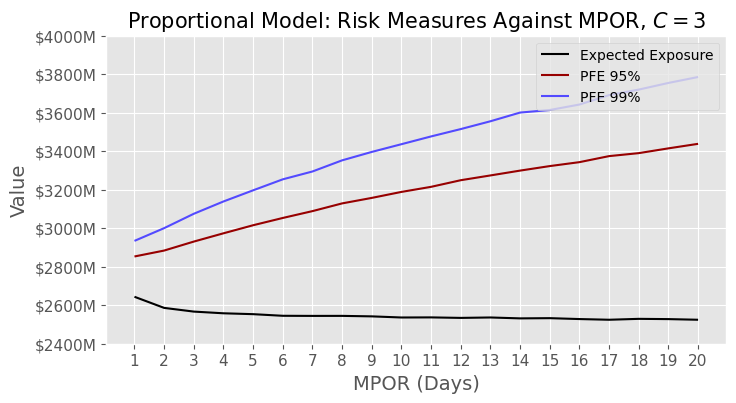

In [7]:
plot_thesis_setup(alternative_colours=False)
plt.plot(list(range(1, MPOR_max + 1)), simulated_expected_losses, label = "Expected Exposure")
plt.plot(list(range(1, MPOR_max + 1)), simulated_pfe_95, label = "PFE 95%")
plt.plot(list(range(1, MPOR_max + 1)), simulated_pfe_99, label = "PFE 99%")
y_ticks = plt.yticks()[0]
plt.yticks(y_ticks, [ r"$" + str(int(tick)) + r"M" if tick >= 0 else "" for tick in y_ticks], fontsize = 11)
x_ticks = list(range(1, MPOR_max + 1))
plt.xticks(x_ticks)
plot_thesis_format(title = "Proportional Model: Risk Measures Against MPOR, $C = 3$", xlabel = "MPOR (Days)", ylabel = "Value", filename = "ProportionalMPORRiskMeasures", save = True)
plt.legend(loc = 'upper right')
plt.show()

In [8]:
sims = 10000
MPOR_max = 20

simulated_expected_losses = []

multipliers = np.linspace(0, 6, 7)

for portfolio_multiplier in multipliers:
    simulated_expected_loss = []
    for MPOR in range(1, MPOR_max + 1):

        times = np.linspace(start, MPOR, steps)

        tick_size  = (MPOR - start) / steps

        primary_agent = StocksAndAgents.Agent({stock_names[i]: ImpactFunctions.TradingProcess(primary_agent_volumes[i], start_times[0], MPOR, risk_aversions[0], times) for i in range(len(stock_names))}, agent_names[0])
        other_agents = StocksAndAgents.Agent({stock_names[i]: ImpactFunctions.TradingProcess(primary_agent_volumes[i] * portfolio_multiplier, start_times[1], MPOR, risk_aversions[1], times) for i in range(len(stock_names))}, agent_names[1])

        agents = [primary_agent, other_agents]

        stock_time_series = UnpeturbedStockPathGeneration.generate_correlated_geometric_brownians(sims, steps, cholesky_root, MPOR/260, means, vols, all_stock_and_index_values)

        #plt.plot(times, stock_time_series[:, :, 0].T)
        #plt.show()

        simulated_agent_names = []
        

        for agent in agents[0:1]:
            i = 0

            cash = 0
            impact_and_trading_costs = 0

            for name in excel_stock_name_order:
                stock_processes = StocksAndAgents.AuxilliaryStockProcesses(times, agents, impact_functions, trading_cost_functions, name, stock_value_dict[name])
                stock_impact_weight = np.exp((stock_processes.trading_volume() - stock_processes.trading_volume()[0]) * stock_processes.impact_function.scale)
                stock_trading_costs = stock_processes.compute_trading_costs()
                stock_series = stock_time_series[:, :, i] * stock_impact_weight
                i += 1

                velocity = agent.trading_processes[name].velocity

                #print(MPOR)
                #print(velocity[0])

                
                cash += compute_cash_process(stock_series, velocity, tick_size)

                impact_and_trading_costs += stock_trading_costs[agent.name]

            losses = -(np.minimum(cash[:, -1] - impact_and_trading_costs[-1] + margins_dict[agent.name] - portfolio_value_dict[agent.name],0))
            #losses = -(cash[:, -1] + margins_dict[agent.name] - portfolio_value_dict[agent.name])
            losses.sort()

            simulated_expected_loss.append(losses.mean())




        disclosed_losses = [5400, 10462-5400]

    
    simulated_expected_losses.append(simulated_expected_loss)


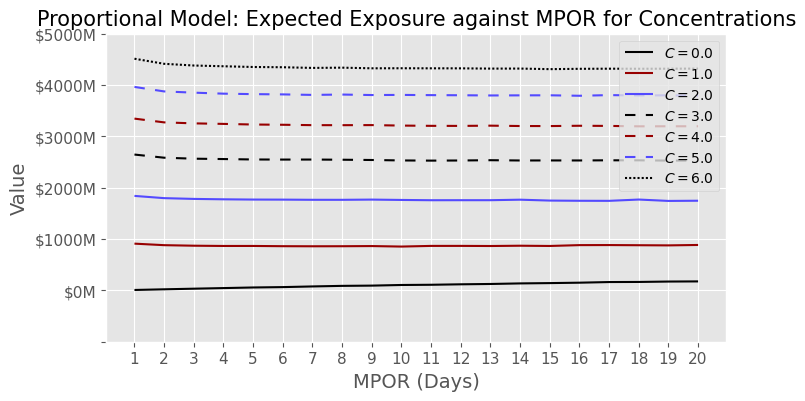

In [9]:
plot_thesis_setup(alternative_colours=False)
i = 0
for multiplier in multipliers:
    plt.plot(list(range(1, MPOR_max + 1)), simulated_expected_losses[i], label = "$C =$" + str(np.round(multiplier,1)))
    i += 1

y_ticks = plt.yticks()[0]
plt.yticks(y_ticks, [ r"$" + str(int(tick)) + r"M" if tick >= 0 else "" for tick in y_ticks], fontsize = 11)
x_ticks = list(range(1, MPOR_max + 1))
plt.xticks(x_ticks)
plot_thesis_format(title = "Proportional Model: Expected Exposure against MPOR for Concentrations", xlabel = "MPOR (Days)", ylabel = "Value", filename = "ProportionalExpectedExposureForConcentrations", save = True)
plt.legend(loc = 'upper right')
plt.show()

In [10]:
sims = 10000
MPOR = 10

simulated_expected_losses = []
simulated_pfe_99 = []
simulated_pfe_95 = []

multipliers = np.linspace(0, 10, 30)

for portfolio_multiplier in multipliers:
    simulated_expected_loss = []

    times = np.linspace(start, MPOR, steps)

    tick_size  = (MPOR - start) / steps

    primary_agent = StocksAndAgents.Agent({stock_names[i]: ImpactFunctions.TradingProcess(primary_agent_volumes[i], start_times[0], MPOR, risk_aversions[0], times) for i in range(len(stock_names))}, agent_names[0])
    other_agents = StocksAndAgents.Agent({stock_names[i]: ImpactFunctions.TradingProcess(primary_agent_volumes[i] * portfolio_multiplier, start_times[1], MPOR, risk_aversions[1], times) for i in range(len(stock_names))}, agent_names[1])

    agents = [primary_agent, other_agents]

    stock_time_series = UnpeturbedStockPathGeneration.generate_correlated_geometric_brownians(sims, steps, cholesky_root, MPOR/260, means, vols, all_stock_and_index_values)

    #plt.plot(times, stock_time_series[:, :, 0].T)
    #plt.show()

    simulated_agent_names = []
    

    for agent in agents[0:1]:
        i = 0

        cash = 0
        impact_and_trading_costs = 0

        for name in excel_stock_name_order:
            stock_processes = StocksAndAgents.AuxilliaryStockProcesses(times, agents, impact_functions, trading_cost_functions, name, stock_value_dict[name])
            stock_impact_weight = np.exp((stock_processes.trading_volume() - stock_processes.trading_volume()[0]) * stock_processes.impact_function.scale)
            stock_trading_costs = stock_processes.compute_trading_costs()
            stock_series = stock_time_series[:, :, i] * stock_impact_weight
            i += 1

            velocity = agent.trading_processes[name].velocity

            #print(MPOR)
            #print(velocity[0])

            
            cash += compute_cash_process(stock_series, velocity, tick_size)

            impact_and_trading_costs += stock_trading_costs[agent.name]

        losses = -(np.minimum(cash[:, -1] - impact_and_trading_costs[-1] + margins_dict[agent.name] - portfolio_value_dict[agent.name],0))
        #losses = -(cash[:, -1] + margins_dict[agent.name] - portfolio_value_dict[agent.name])
        losses.sort()

        simulated_expected_losses.append(losses.mean())
        simulated_pfe_99.append(losses[int(sims *0.99)])
        simulated_pfe_95.append(losses[int(sims *0.95)])

    
    


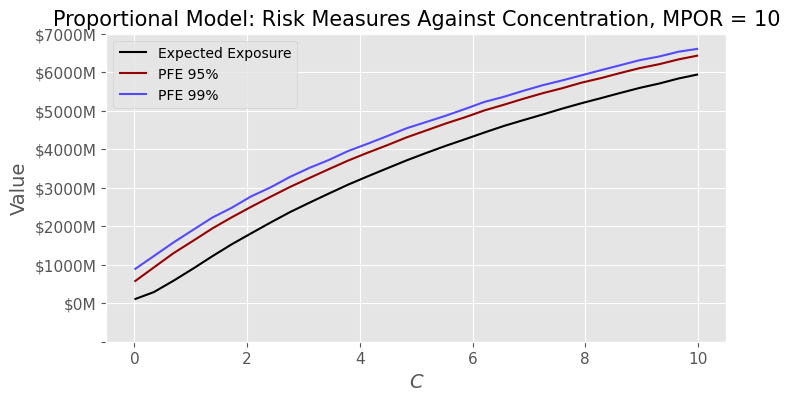

In [11]:
plot_thesis_setup(alternative_colours=False)
plt.plot(multipliers, simulated_expected_losses, label = "Expected Exposure")
plt.plot(multipliers, simulated_pfe_95, label = "PFE 95%")
plt.plot(multipliers, simulated_pfe_99, label = "PFE 99%")

y_ticks = plt.yticks()[0]
plt.yticks(y_ticks, [ r"$" + str(int(tick)) + r"M" if tick >= 0 else "" for tick in y_ticks], fontsize = 11)
plot_thesis_format(title = "Proportional Model: Risk Measures Against Concentration, MPOR = 10", xlabel = "$C$", ylabel = "Value", filename = "ProportionalRiskMeasuresAgainstConcentration", save = True)
plt.legend(loc = 'upper left')
plt.show()

In [12]:
print(simulated_pfe_95)
print(simulated_pfe_99)
print(simulated_expected_losses)

[np.float64(562.2858272996418), np.float64(930.0980403723115), np.float64(1296.7086387711024), np.float64(1615.9169191716428), np.float64(1940.207643054615), np.float64(2229.9255917831833), np.float64(2503.0614633102814), np.float64(2764.5837102261758), np.float64(3019.1879465626844), np.float64(3252.116535331832), np.float64(3481.856748762788), np.float64(3706.5122588806207), np.float64(3909.84150008315), np.float64(4103.372376595218), np.float64(4307.306350814852), np.float64(4485.168081127114), np.float64(4665.416093136657), np.float64(4828.8395529014815), np.float64(5007.273151896525), np.float64(5154.516693831982), np.float64(5309.23271109023), np.float64(5454.400045673041), np.float64(5583.383740995945), np.float64(5728.327220259187), np.float64(5846.973171897249), np.float64(5980.612018451808), np.float64(6107.143018662517), np.float64(6208.849253800296), np.float64(6333.84760533151), np.float64(6434.3751367379045)]
[np.float64(877.9221177738309), np.float64(1226.1471792202246),